<a href="https://colab.research.google.com/github/saminNazmus201/DeepLearningDataScienceUppsala/blob/master/Exercise4Ass2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn.functional as F
import time
from utils import load_mnist, training_curve_plot

In [2]:
!unzip -q MNIST.zip   #unzip the file

In [3]:
x_train_np, y_train_np, x_test_np, y_test_np = load_mnist()

In [4]:
# We reshape from (60000, 784) to (60000, 1, 28, 28)
x_train = torch.from_numpy(x_train_np).view(-1, 1, 28, 28).float()
x_test = torch.from_numpy(x_test_np).view(-1, 1, 28, 28).float()

y_train = torch.from_numpy(y_train_np).long()
y_test = torch.from_numpy(y_test_np).long()

# Convert One-Hot to Indices if necessary (F.cross_entropy needs indices)
if y_train.dim() > 1:
    y_train = y_train.argmax(dim=1)
    y_test = y_test.argmax(dim=1)

In [5]:
def initialize_residual_cnn():
    def make_w(shape):
        fan_in = shape[1] * shape[2] * shape[3] #number of input
        w = torch.randn(shape) * torch.sqrt(torch.tensor(2.0 / fan_in))
        w.requires_grad = True
        return w
    weights = [
        make_w((8, 1, 3, 3)),
        make_w((8, 8, 3, 3)),  #residual block
        make_w((8, 8, 3, 3)),   #residual block
        make_w((16, 8, 3, 3)),
        make_w((32, 16, 3, 3)),
        torch.randn(10, 1568) * torch.sqrt(torch.tensor(2.0 / 1568)) # FC
    ]
    for w in weights: w.requires_grad = True

    biases = [torch.full((w.shape[0],), 0.01, requires_grad=True) for w in weights]
    return weights, biases

In [6]:
def forward_pass_residual(X, weights, biases):
    # Initial Layer
    x = F.relu(F.conv2d(X, weights[0], biases[0], padding=1))

    identity = x

    out = F.relu(F.conv2d(x, weights[1], biases[1], padding=1))
    out = F.conv2d(out, weights[2], biases[2], padding=1) #this is residual function

    # Residual addition, F(x) + x
    x = F.relu(out + identity)

    x = F.max_pool2d(x, 2)
    x = F.max_pool2d(F.relu(F.conv2d(x, weights[3], biases[3], padding=1)), 2)
    x = F.relu(F.conv2d(x, weights[4], biases[4], padding=1))

    x = x.view(x.size(0), -1)
    logits = F.linear(x, weights[5], biases[5])
    return logits

In [14]:
import torch.optim as optim

def train_residual_cnn(x_train, y_train, x_test, y_test, num_epochs=15, lr=0.05, batch_size=64):
    weights, biases = initialize_residual_cnn()
    optimizer = optim.Adam(weights + biases)

    # Initialize all four lists for the plotting function
    train_costs, test_costs = [], []
    train_accs, test_accs = [], []

    for epoch in range(num_epochs):
        # --- Training Phase ---
        indices = torch.randperm(x_train.size(0))
        for i in range(0, x_train.size(0), batch_size):
            batch_idx = indices[i:i+batch_size]

            optimizer.zero_grad()
            logits = forward_pass_residual(x_train[batch_idx], weights, biases)
            loss = F.cross_entropy(logits, y_train[batch_idx])
            loss.backward()
            optimizer.step()

        # --- Evaluation Phase (Optimized with Batches) ---
        def get_metrics(X, Y):
            total_loss = 0
            total_correct = 0
            eval_batch = 512 # Processes in chunks to prevent memory freeze
            with torch.no_grad():
                for j in range(0, X.size(0), eval_batch):
                    x_b, y_b = X[j:j+eval_batch], Y[j:j+eval_batch]
                    out = forward_pass_residual(x_b, weights, biases)
                    total_loss += F.cross_entropy(out, y_b).item() * x_b.size(0)
                    total_correct += (out.argmax(dim=1) == y_b).sum().item()
            return total_loss / X.size(0), total_correct / X.size(0)

        # Compute metrics for both sets
        t_loss, t_acc = get_metrics(x_train, y_train)
        v_loss, v_acc = get_metrics(x_test, y_test)

        # Append to lists
        train_costs.append(t_loss)
        test_costs.append(v_loss)
        train_accs.append(t_acc)
        test_accs.append(v_acc)

        # Print the specific format you requested
        print(f"Epoch {epoch+1}: Train Loss {t_loss:.4f}, Test Acc {v_acc:.4f}")

    return weights, biases, train_costs, test_costs, train_accs, test_accs

Epoch 1: Train Loss 0.0474, Test Acc 0.9847
Epoch 2: Train Loss 0.0352, Test Acc 0.9863
Epoch 3: Train Loss 0.0292, Test Acc 0.9851
Epoch 4: Train Loss 0.0259, Test Acc 0.9884
Epoch 5: Train Loss 0.0181, Test Acc 0.9895
Epoch 6: Train Loss 0.0175, Test Acc 0.9877
Epoch 7: Train Loss 0.0100, Test Acc 0.9899
Epoch 8: Train Loss 0.0143, Test Acc 0.9881
Epoch 9: Train Loss 0.0079, Test Acc 0.9895
Epoch 10: Train Loss 0.0053, Test Acc 0.9926


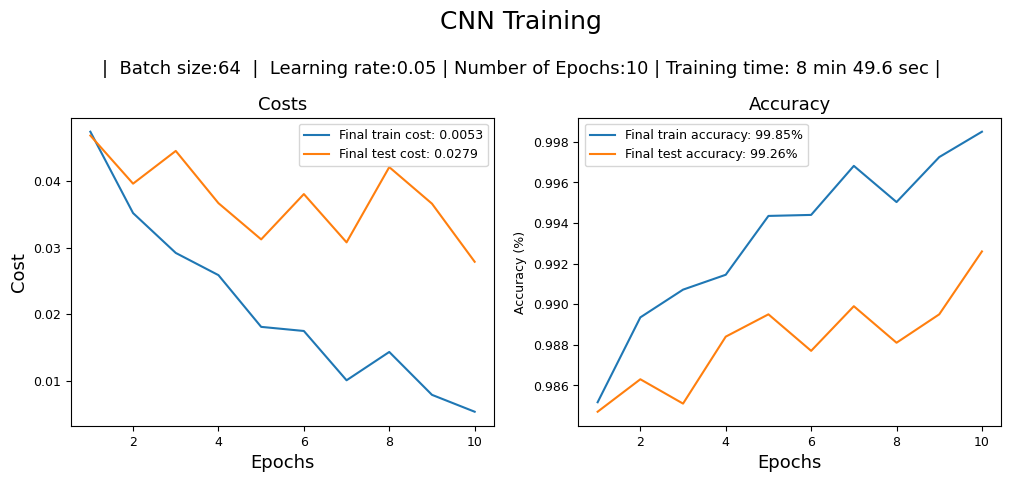

In [15]:
import time
from utils import training_curve_plot

# Parameters
learning_rate = 0.05
batch_size = 64
num_epochs = 10

# Reshape data once to 4D: (Batch, Channels, Height, Width)
x_train_cnn = x_train.view(-1, 1, 28, 28)
x_test_cnn = x_test.view(-1, 1, 28, 28)

start_time = time.time()

# Train
w_cnn, b_cnn, t_costs, v_costs, t_accs, v_accs = train_residual_cnn(
    x_train_cnn, y_train, x_test_cnn, y_test,
    num_epochs=num_epochs, lr=learning_rate, batch_size=batch_size
)

# Plotting - Pass all four lists
training_curve_plot(
    "CNN Training",
    t_costs, v_costs, t_accs, v_accs,
    batch_size, learning_rate, num_epochs, time.time() - start_time
)